In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
df = pd.read_csv("../../datasets/data_banknote_authentication.txt", header= None, encoding = 'utf-8')

In [3]:
df.tail()

,0,1,2,3,4
1367,0.40614,1.34920,-1.4501,-0.55949,1
1368,-1.38870,-4.87730,6.4774,0.34179,1
1369,-3.75030,-13.45860,17.5932,-2.77710,1
1370,-3.56370,-8.38270,12.3930,-1.28230,1
1371,-2.54190,-0.65804,2.6842,1.19520,1


In [4]:
import numpy as np

class Perceptron: 
    def __init__(self, eta=0.01, n_iters=50, random_state=1):
        self.eta = eta
        self.n_iters = n_iters
        self.random_state = random_state

    def fit(self, X, y):  
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=X.shape[1])
        self.b_ = 0.0
        self.errors_ = []

        
        for _ in range(self.n_iters):  
            errors = 0
            for xi, target in zip(X, y):
                update = self.eta * (target - self.predict(xi))
                self.w_ += update * xi 
                self.b_ += update      
            
                errors += int(update != 0.0) 
            self.errors_.append(errors)
        return self

    def net_input(self, X):
        ni = np.dot(X, self.w_) + self.b_
        return ni

    def predict(self, X):
        # Keep in mind: if using 1 and 0 labels, make sure your target y array uses 1 and 0 too!
        return np.where(self.net_input(X) >= 0.0, 1,0)


In [5]:
#To split the dataset into train and test data to train the 
from sklearn.model_selection import train_test_split
X = df.drop(columns=[4])
y = df[4]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2, random_state = 0, stratify = y)
X_train.shape, X_test.shape, X.shape, y_train.shape, y_test.shape

((1097, 4), (275, 4), (1372, 4), (1097,), (275,))

In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

scaler.fit(X_train)

#Transforming both the test and trianing set 
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
scaler.mean_

array([ 0.46209873,  1.84119166,  1.43895498, -1.13762343])

In [8]:
X_train

,0,1,2,3
1157,-5.204900,7.2590,0.070827,-7.30040
1210,0.025013,3.3998,-4.432700,-4.26550
909,-1.732200,-9.2828,7.719000,-1.71680
255,4.142500,-3.6792,3.828100,1.62970
584,0.335650,6.8369,0.697180,-0.55691
...,...,...,...,...
905,0.745210,3.6357,-4.404400,-4.14140
443,3.670200,2.9942,0.851410,0.30688
493,2.808400,11.3045,-3.339400,-4.41940
877,-5.121600,-5.3118,10.384600,-1.06120


In [9]:
#X_train_scaled = pd.DataFrame(X_train_scaled, columns = X_train.columns)
#X_test_scaled = pd.DataFrame(X_test_scaled,columns = X_test.columns)

In [10]:
X_train_scaled

array([[-1.99716738,  0.92559028, -0.31525515, -3.01395492],
       [-0.15403804,  0.26627607, -1.35299439, -1.52971292],
       [-0.77331618, -1.90044717,  1.44709894, -0.28325091],
       ...,
       [ 0.82688502,  1.61673238, -1.10106733, -1.60497894],
       [-1.96781074, -1.22203281,  2.06132812,  0.03737549],
       [-0.63065631,  1.30810595,  0.23085326, -2.02043368]],
      shape=(1097, 4))

In [11]:
# X_train_scaled.describe().round() - to see the mean and sd . Checked and converted it back to numpy array

Preprocessing completed:  1) Standardization done ie a part of feature scaling as the values were very far apart 
                          2) Dataset split into testing data and training data

Since the data I have currently is 4d I have to transform it into 2d or 1d. The most widely used method for this is PCA - Principle Component Analysis

In [12]:
# Step 1 is making the data mean centric but since I already applied standardization to the data no need to do that

In [13]:
# Step 2 is finding the covariance matrix
covariance_matrix = np.cov(X_train_scaled, rowvar = False)
print('Covariance Matrix:\n', covariance_matrix)

Covariance Matrix:
 [[ 1.00091241  0.27699964 -0.39315434  0.2582944 ]
 [ 0.27699964  1.00091241 -0.79007944 -0.52492656]
 [-0.39315434 -0.79007944  1.00091241  0.31941804]
 [ 0.2582944  -0.52492656  0.31941804  1.00091241]]


In [14]:
# Step 3 is finding the eigen values and eigen vectors 
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)
#np.linearalgebra.eigenvalues

In [15]:
eigen_values

array([2.19473847+0.j, 1.27765777+0.j, 0.35654986+0.j, 0.17470354+0.j])

In [16]:
eigen_vectors

array([[-0.26577702+0.j, -0.74778911+0.j,  0.60590433+0.j,
         0.05526279+0.j],
       [-0.63667477+0.j,  0.06046949+0.j, -0.13562833+0.j,
        -0.75669917+0.j],
       [ 0.61222488+0.j,  0.14520572+0.j,  0.5018867 +0.j,
        -0.59346923+0.j],
       [ 0.38624928+0.j, -0.64503503+0.j, -0.60215832+0.j,
        -0.26860131+0.j]])

In [17]:
pc = eigen_vectors[0:2] #Fetching the top two eigen vectors
pc

array([[-0.26577702+0.j, -0.74778911+0.j,  0.60590433+0.j,
         0.05526279+0.j],
       [-0.63667477+0.j,  0.06046949+0.j, -0.13562833+0.j,
        -0.75669917+0.j]])

In [18]:
transformed_df = np.dot(X_train_scaled,pc.T)
new_df = pd.DataFrame(transformed_df,columns=['PC1','PC2'])
new_df['target'] = y
new_df.tail()

,PC1,PC2,target
1092,-1.152789+0.000000j,1.249242+0.000000j,1
1093,-0.490780+0.000000j,-1.224119+0.000000j,1
1094,-2.184579+0.000000j,0.935128+0.000000j,1
1095,2.687855+0.000000j,0.871103+0.000000j,1
1096,-0.782353+0.000000j,1.978174+0.000000j,1


c:\Users\laksh\Downloads\journey_of_ML\.venv\Lib\site-packages\matplotlib\cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\laksh\Downloads\journey_of_ML\.venv\Lib\site-packages\matplotlib\collections.py:205: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


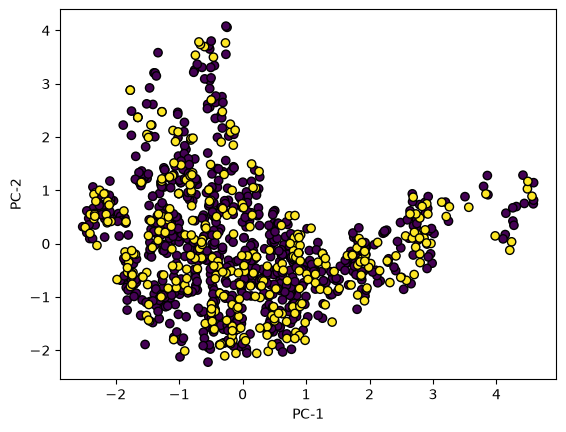

In [19]:
plt.scatter(new_df['PC1'], new_df['PC2'], c=new_df['target'], edgecolor='k')
plt.xlabel('PC-1')
plt.ylabel('PC-2')
plt.show()


Since toning down the 4 features of the dataset into 2 pca, we couldnt see if the dataset was linearly seperable or not. We will train the model on the original 4 features only

Text(0, 0.5, 'Number of updates')

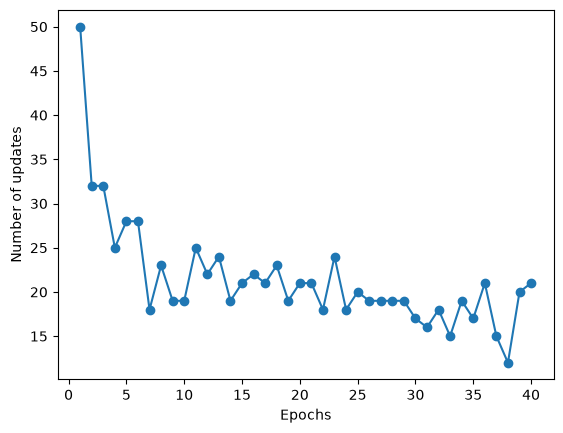

In [20]:
ppn = Perceptron(eta = 0.01,n_iters = 40)
ppn.fit(X_train_scaled, y_train)
plt.plot(range(1,len(ppn.errors_)+1),ppn.errors_,marker='o')
plt.xlabel("Epochs")
plt.ylabel("Number of updates")

Kept the epochs to only 40 as it hit the minimum number of errors at iteration 37 or 38 ie 11 or 12